<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_6/Chapter06/decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Decision Trees

Machine learning algorithms that can perform both classification and regression tasks, and even multioutput tasks

## Training and Visualizing a Decision Tree

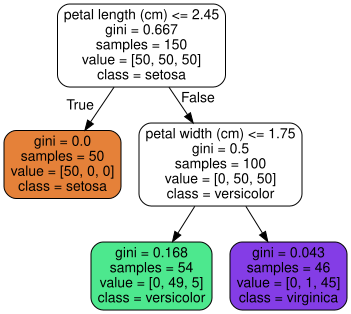

In [1]:
# Train DecisionTreeClassifier on the iris dataset

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

# Visualize the trained decision tree

from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

from graphviz import Source

Source.from_file("iris_tree.dot")

- gini: measures *Gini impurity*
- If a node is "pure", gini=0, when all training instances belong to the same class
- For class=versicolor node
$$
1 - (\frac{0}{54})^2 - (\frac{49}{54})^2 - (\frac{5}{54})^2 = 0.168
$$
- Gini Impurity
$$
G_i = 1 - \sum_{k=1}^n p_{i,k}^2
$$
  where
  - $G_i$ is the Gini impurity of the $i^{th}$ node
  - $P_{i,k}$ is the ratio of class $k$ instances among the training instances in the $i^{th}$ node

- Scikit-Learn uses the CART algorithm, which produces only binary trees, only two children nodes (yes or no answers)
- Other algorithms such as ID3 can produce children nodes with more than two children

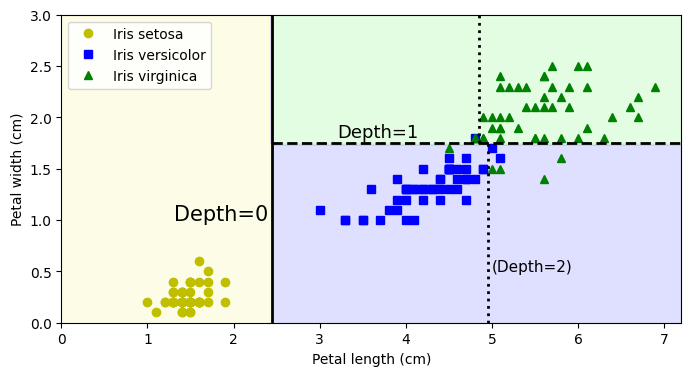

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

- If set max_depth to 3, two vertical dotted lines represent the decision boundary

## Estimating Class Probabilities

- 0% for Iris setosa (0/54)
- 90.7% for Iris versicolor (49/54)
- 9.3% for Iris virginica (5/54)

Output will be the class with the highest probability

In [3]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [4]:
tree_clf.predict([[5, 1.5]])

array([1])

## The CART Training Algorithm

- Classification and Regression Tree (CART)
- The algorithm works by first splitting the training set into two subsets using a single feature $k$ and a threshold $t_k$ (eg. petal length $\le$ 2.45cm)
- It searches for the pair ($k$, $t_k$) that produces the purest subsets
- CART cost function for classification
$$
J(k, t_k) = \frac{m_{left}}{m}G_{left} + \frac{m_{right}}{m}G_{right}
$$
  where:
  - $G_{left/right}$ measures the impurity of the left/right subset
  - $m_{left/right}$ is the number of instances in the left/right subset
- Once the training set is split in two, it splits the subsets using the same logic, then the sub-subsets, and so on until it reaches the depth defined by the **max_depth** hyperparameter
- Additional hyperparameters to control stopping condition:
  - min_samples_split
  - min_samples_leaf
  - min_weight_fraction_leaf
  - max_leaf_nodes

## Computational Complexity

- Traversing the decision tree requires going through roughly $O(log_2(m)$ nodes, where $log_2(m)$ is the binary logarithm of $m$
- Prediction complexity is independent of the number of features

## Gini Impurity or Entropy?

- *DecisionTreeClassifier* class uses the Gini impurity measure by default
- Setting the *criterion* hyperparameter to "entropy" to select the *entropy* impurity
- A set's entropy is zero when it contains instances of only one class
- Entropy equation
$$
H_i = -\sum_{k=1}^{n} P_{i,k} log_2(P_{i,k})
$$
- Refer to the decision tree above for the node with class = versicolor
$$
\begin{aligned}
Entropy &= -\frac{49}{54}log_2(\frac{49}{54}) - \frac{5}{54}log_(\frac{5}{54}) \\
&= 0.445
\end{aligned}
$$

- Gini impurity and entropy lead to the same trees
- Gini is slightly faster, a good default
- Gini tends to isolate the most frequent class in its own brnach of the tree
- Entropy tends to produce slightly more balanced trees

## Regularization Hyperparameters

- To avoid overfitting, restrict the decision tree's freedom during training (regularization)
- max_depth
  - restrict the maximum depth of the decision tree
  - default is none
- max_features
  - maximum number of features that are evaluated for splitting at each node
- max_leaf_nodes
  - maximum number of leaf nodes
- min_samples_split
  - minimum number of samples a node must have before it can be split
- min_samples_leaf
  - minimum number of samples of leaf node must have to be created
- min_weight_fraction_leaf
  - same as *min_samples_leaf* but expressed as a fracction of the total number of weighted instances
- Increasing min_* hyperparameters or reducing max_* hyperparameters will regularize the model

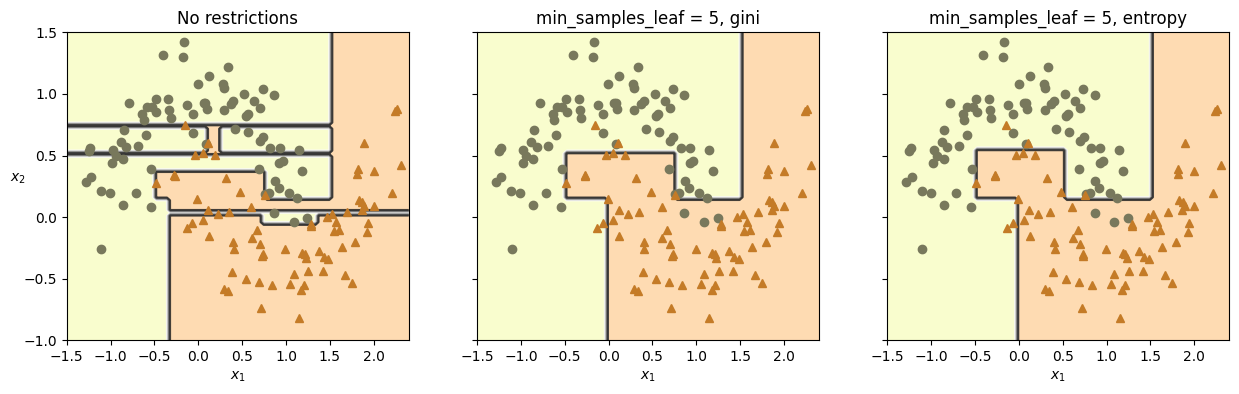

In [5]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf3 = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=5, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)
tree_clf3.fit(X_moons, y_moons)

# Plot
def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=3, figsize=(15, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons, axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons, axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}, {tree_clf2.criterion}")
plt.ylabel("")
plt.sca(axes[2])
plot_decision_boundary(tree_clf3, X_moons, y_moons, axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf3.min_samples_leaf}, {tree_clf3.criterion}")
plt.ylabel("")

plt.show()

- Left plot is unregularized (overfitting)
- Right plot is regularized, it will generalize better

In [6]:
# Verify
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)

In [7]:
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [8]:
# Verify that the regularized tree has a better accuracy on the test set
tree_clf2.score(X_moons_test, y_moons_test)

0.92

In [9]:
# Score for entropy impurity
tree_clf3.score(X_moons_test, y_moons_test)

0.933

## Regression

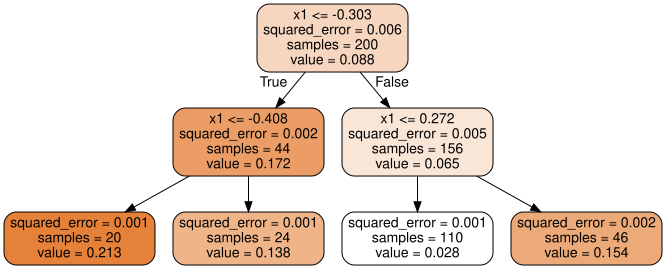

In [12]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200,1) - 0.5
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200,1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

# Visualize decision tree
export_graphviz(
    tree_reg,
    out_file="regression_tree.dot",
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file("regression_tree.dot")

- Predicts a value instead of a class
- eg. To make a prediction for a new instance with $x_i = 0.2$
  - root node asks whether $x_i \le -0.303$
  - Since it is not, algorithm goes to the right child node
  - Is $x_1 \le 0.2702$
  - Yes, algorithm goes to the left leaf node, predicts a value of 0.028
  - Prediction is the average target value of the 110 samples

In [16]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

print("Tree 1", tree_reg.tree_.threshold)
print("\nTree 2:", tree_reg2.tree_.threshold)

Tree 1 [-0.30265072 -0.40830374 -2.         -2.          0.27175756 -2.
 -2.        ]

Tree 2: [-0.30265072 -0.40830374 -0.45416115 -2.         -2.         -0.37022041
 -2.         -2.          0.27175756 -0.21270403 -2.         -2.
  0.40399227 -2.         -2.        ]


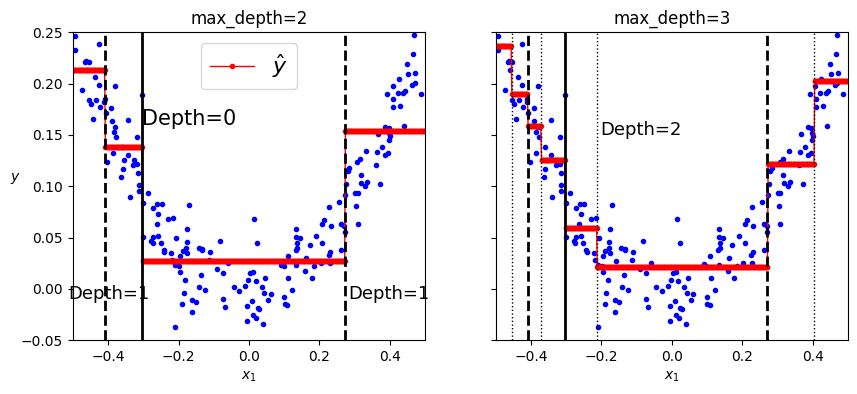

In [18]:
def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=1, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

plt.show()

- Red horizontal line $(\hat{y})$ is the prediction value of each child leaf nodes
- Split each region in a way that makes most training instances as close as possible to the predicted value

- CART algorithm in regression split in a way that minimizes the MSE instead of splitting of splitting the training set in a way that minimizes impurity
- Decision trees without any regularization will also overfit

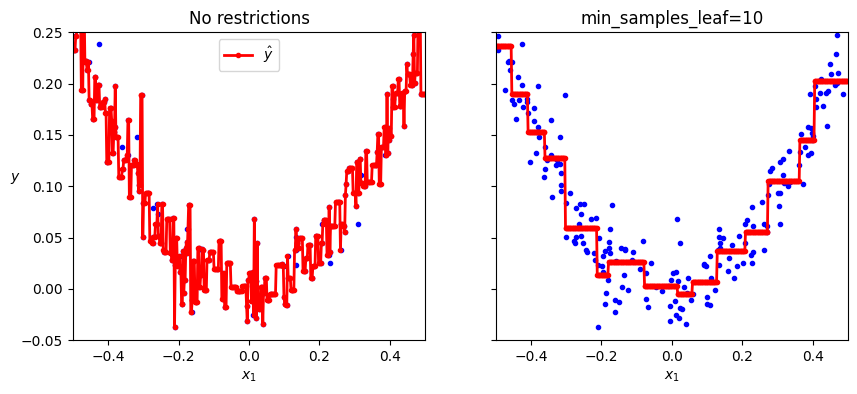

In [19]:
# Default hyperparameters vs regularization

tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

plt.show()

## Sensitivity to Axis Orientation

- Decision trees love orthogonal decision boundaries, splits are perpendicular to an axis
- Sensitive to data's orientation

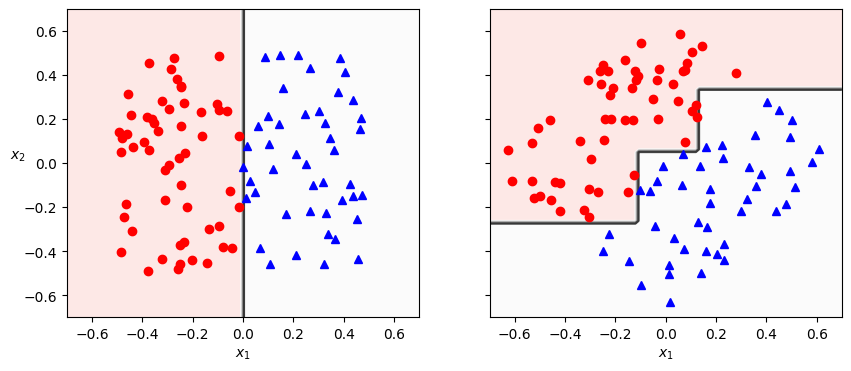

In [20]:
# Rotate data by 45°
# Model on the right will not generalize well

np.random.seed(6)
X_square = np.random.rand(100, 2) - 0.5
y_square = (X_square[:, 0] > 0).astype(np.int64)

angle = np.pi / 4  # 45 degrees
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])
X_rotated_square = X_square.dot(rotation_matrix)

tree_clf_square = DecisionTreeClassifier(random_state=42)
tree_clf_square.fit(X_square, y_square)
tree_clf_rotated_square = DecisionTreeClassifier(random_state=42)
tree_clf_rotated_square.fit(X_rotated_square, y_square)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf_square, X_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.sca(axes[1])
plot_decision_boundary(tree_clf_rotated_square, X_rotated_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.ylabel("")

plt.show()

- To limit this problem, scale the data then apply principal component analysis (PCA) transformation. To be discussed in chapter 8

In [22]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

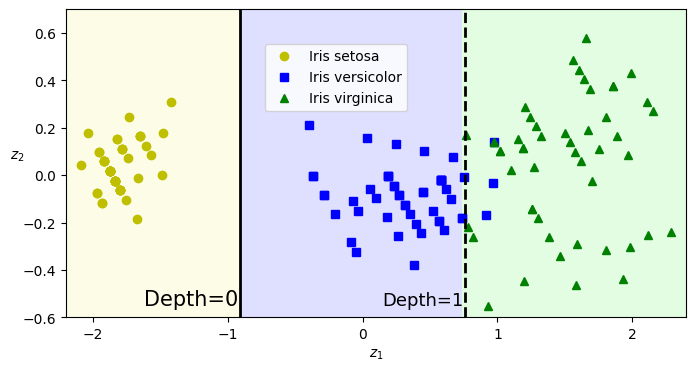

In [23]:
plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_rotated[:, 0][y_iris == idx],
             X_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))

plt.show()

## Decision Trees Have a High Variance

- High variance: small changes to the hyperparameters or to the data may produce very different models

Show that training the same model on the same data may produce a very different model every time, since the CART training algorithm used by Scikit-Learn is stochastic. To show this, set random_state to a different value than earlier:

In [24]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=40)

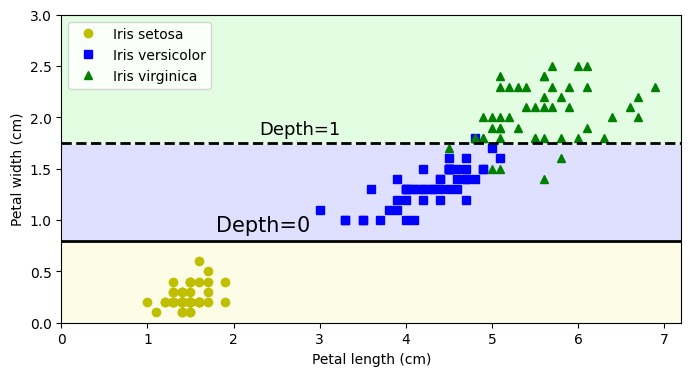

In [25]:
plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

- To reduce variance significantly, average predictions over many trees
- This ensemble of trees is called a *random forest* (Chapter 7)

## Exercises

1. What is the approximate depth of a decision tree trained (without restrictions) on a training set with one million instances?
   - Wihthout restrictions, the hyperparameter *min_samples_leaf* is 1
   - $depth=log_2​(N)$
   - $$
   \begin{aligned}
   log_2(10^6) &= \frac{log_{10}(10^6)}{log_{10}(2)} \\
   &≈ 20
   \end{aligned}
   $$

2. Is a node's Gini impurity genrally lower or higher than its parent's? Is it genrally lower/higher, or always lower/higher?
   - A node's Gini impurity is generally lower than its parent's. This is due to the CART training algorithm's cost function, which splits each node in a way that minimizes the weighted sum of its children's Gini impurities.
   - However, it is possible for a node to have a higher Gini impurity than its parent, as long as this increase is more than compensated for by a decrease in the other child's impurity.
   - For example, consider a node containing four instances of class A and one of class B. Its Gini impurity is 1 – (1/5)² – (4/5)² = 0.32.
   - Now suppose the dataset is one-dimensional and the instances are lined up in the following order: A, B, A, A, A. You can verify that the algorithm will split this node after the second instance, producing one child node with instances A, B, and the other child node with instances A, A, A. The first child node's Gini impurity is 1 – (1/2)² – (1/2)² = 0.5, which is higher than its parent's. This is compensated for by the fact that the other node is pure, so its overall weighted Gini impurity is 2/5 × 0.5 + 3/5 × 0 = 0.2, which is lower than the parent's Gini impurity.

3. If a decision tree is overfitting the training set, is it a good idea to try decreasing max_depth?
   - It may be a good idea to decrease max_depth, since this will constrain the model, regularizing it.

4. If a decision tree is underfitting the training set, is it a good idea to try scaling the input features?
   - No, scaling input features will not fix an underfitting decision tree
   - The relative order of samples is unchanged

5. If it takes one hour to train a decision tree on a training set containing one million instances, roughly how much time will it take to train another decision tree on a training set containing ten million instances? Hint: consider the CART algorithm's computational complexity.
   - The computational complexity of training a Decision Tree is $O(n × m log₂(m))$. So if you multiply the training set size by 10, the training time will be multiplied by
   $$
   \begin{aligned}
   K &= \frac{(n × 10 m × log₂(10 m))}{(n × m × log₂(m))} \\
   &= 10 × log₂(10 m) / log₂(m)
   \end{aligned}
   $$
   - If m = 106, then K ≈ 11.7, so you can expect the training time to be roughly 11.7 hours.

6. If it takes one hour to train a decision tree on a given training set, roughly how much time will it take if you double the number of features?
   - If the number of features doubles, then the training time will also roughly double.

7. Train and fine-tune a decision tree for the moons dataset by following these steps:
   <ol type="a">
    <li>Use make_moons(n_samples=10000, noise=0.4) to generate a moons dataset</li>
    <li>Use train_test_split() to split the dataset into a training set and a test set</li>
    <li>Use grid search with cross-validation (with the help of the GridSearchCV class) to find good hyperparameter values for a DecisionTreeClassifier. Hint: try various values for max_leaf_nodes</li>
    <li>Train it on the full training set using these hyperparameters, and measure your model's performance on the test set. You should get roughly 85% to 87% accuracy</li>
   </ol>



In [28]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

X_moons, y_moons = make_moons(n_samples=10000, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

param_grid = [
    {'max_leaf_nodes': list(range(2, 100)),
     'min_samples_split': [2, 3, 4],
     'max_depth': list(range(2,8))}
]

grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search_cv.fit(X_train, y_train)

Fitting 3 folds for each of 1764 candidates, totalling 5292 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid=[{'max_depth': [2, 3, 4, 5, 6, 7],
                          'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                             13, 14, 15, 16, 17, 18, 19, 20, 21,
                                             22, 23, 24, 25, 26, 27, 28, 29, 30,
                                             31, ...],
                          'min_samples_split': [2, 3, 4]}],
             verbose=1)

In [29]:
grid_search_cv.best_params_

{'max_depth': 7, 'max_leaf_nodes': 17, 'min_samples_split': 2}

In [31]:
grid_search_cv.best_estimator_.fit(X_train, y_train)
grid_search_cv.score(X_test, y_test)

0.8695

In [37]:
# Alternative method using accuracy_score class

from sklearn.metrics import accuracy_score

accuracy_score(y_test, grid_search_cv.best_estimator_.predict(X_test))

0.8695

8. Grow a forest by following these steps:
   <ol type="a">
    <li>Continuing the previous exercise, generate 1000 subsets of the training set, each containing 100 instances selected randomly. Hint: you can use Scikit-Learn's ShuffleSplit class for this</li>
    <li>Train one decision tree on each subset, using the best hyperparameter values found in the previous exercise. Evaluate these 1000 decision trees on the test set. Since they were trained on smaller sets, these decision trees will likely perform worse than the first decision tree, achieving only about 80% accuracy</li>
    <li>Now comes the magic. For each test set instance, generate the predictions of the 1000 decision trees, and keep only the most frequent prediction (you can use SciPy's mode() function for this). This approach gives you majority-vote predictions over the test set</li>
    <li>Evaluate these predictions on the test set: you should obtain a slightly higher accuracy than your first model (about 0.5 to 1.5% higher). Congratulations, you have trained a random forest classifier!</li>
   </ol>

In [32]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []

rs = ShuffleSplit(n_splits=n_trees, test_size=len(X_train) - n_instances,
                  random_state=42)

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

In [34]:
from sklearn.base import clone

forest = [clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]

accuracy_scores = []

for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    tree.fit(X_mini_train, y_mini_train)

    y_pred = tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

np.mean(accuracy_scores)

np.float64(0.8051575000000001)

In [35]:
Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)

for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

from scipy.stats import mode

y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)

In [36]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.8735